## Load the tokenizer

In [1]:
import sys
sys.path.append('..')

In [2]:
from minbpe import BasicTokenizer

tokenizer = BasicTokenizer()
tokenizer.load(model_file="../output/tokenizer/my_tokenizer.model")


def get_vocab_size(tokenizer: BasicTokenizer) -> int:
    vocab = tokenizer.vocab
    special_tokens = tokenizer.special_tokens

    return len(vocab) + len(special_tokens)

## Create the model

In [3]:
import torch
torch.manual_seed(3647)
torch.set_float32_matmul_precision('high')

In [4]:
from variant_gpt.models import GPT2Config, GPT2Model

config = GPT2Config(
    vocab_size=get_vocab_size(tokenizer),
    dropout=0.1,
    device='cuda:0' if torch.cuda.is_available() else 'cpu',
    flash=True
)

model = GPT2Model(config)
model = torch.compile(model)

print(sum(p.numel() for p in model.parameters())/1e6, 'M parameters')

number of parameters: 85.85M
86.636544 M parameters


## Data preparation

### 1. Load the data

In [5]:
import os
import pickle

text_path = "../output/combined_text.txt"
encoded_path = "../output/encoded_text.pkl"

if os.path.exists(encoded_path):
    print("Loading encoded sequence from file...")
    with open(encoded_path, "rb") as f:
        encoded_text_sequence = pickle.load(f)
else:
    print("Encoding text...")
    with open(text_path, "r", encoding="utf-8") as f:
        text_sequence = f.read()

    encoded_text_sequence = tokenizer.encode(text_sequence)

    print("Saving encoded sequence to file...")
    with open(encoded_path, "wb") as f:
        pickle.dump(encoded_text_sequence, f)

print(f"Length of encoded sequence: {len(encoded_text_sequence)}")

Loading encoded sequence from file...
Length of encoded sequence: 816962


### 2. Split it into train and test

In [6]:
data = torch.tensor(encoded_text_sequence, dtype=torch.long)
split_index = int(0.9 * len(data))
train_data = data[:split_index]
val_data = data[split_index:]

### 3. Data loader

In [7]:
from typing import Tuple
from torch.utils.data import Dataset, DataLoader


class TextDataset(Dataset):
    def __init__(self, data: torch.Tensor, block_size: int) -> None:
        if len(data) <= block_size:
            raise ValueError(
                f"The length of the data ({len(data)}) must be greater than the block_size ({block_size})."
            )

        self.data = data
        self.block_size = block_size

    def __len__(self) -> int:
        return len(self.data) - self.block_size

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor]:
        x = self.data[index : index + self.block_size]
        y = self.data[index + 1 : index + self.block_size + 1]
        return x, y


def get_dataloaders(
    train_data: torch.Tensor,
    val_data: torch.Tensor,
    block_size: int,
    batch_size: int,
    device: torch.device,
) -> Tuple[DataLoader, DataLoader]:
    train_dataset = TextDataset(train_data.to(device), block_size)
    val_dataset = TextDataset(val_data.to(device), block_size)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
    )

    return train_loader, val_loader

In [8]:
batch_size = 96

train_loader, val_loader = get_dataloaders(
    train_data=train_data,
    val_data=val_data,
    block_size=config.block_size,
    batch_size=batch_size,
    device=config.device,
)
x, y = next(iter(train_loader))
x.shape, y.shape

(torch.Size([96, 1024]), torch.Size([96, 1024]))

### 4. Training

In [9]:
from typing import Dict


@torch.no_grad()
def estimate_loss(
    model: torch.nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    eval_iters: int
) -> Dict[str, float]:
    was_training = model.training
    model.eval()

    results: Dict[str, float] = {}

    for split_name, loader in [('train', train_loader), ('val', val_loader)]:
        losses = []

        for i, (x, y) in enumerate(loader):
            if i >= eval_iters:
                break

            # Expecting model to return (logits, loss)
            with torch.autocast("cuda", dtype=torch.bfloat16):
                _, loss = model(x, y)
            losses.append(loss.item())

        results[split_name] = float(torch.tensor(losses).mean())

    if was_training:
        model.train()

    return results

In [10]:
def save_checkpoint(
    model: GPT2Model,
    optimizer: torch.optim.Optimizer,
    epoch: int,
    loss: float,
    file_path: str = "checkpoint.pth"
) -> None:
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss
    }
    torch.save(checkpoint, file_path)

In [11]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best_val_loss = float('inf')
        self.stale_count = 0

    @property
    def should_stop(self) -> bool:
        return self.stale_count >= self.patience

    def step(self, val_loss: float) -> bool:
        """Update state. Returns True if this is a new best."""
        if val_loss < self.best_val_loss - self.min_delta:
            self.best_val_loss = val_loss
            self.stale_count = 0
            return True
        self.stale_count += 1
        return False

In [12]:
env CUDA_LAUNCH_BLOCKING=1

env: CUDA_LAUNCH_BLOCKING=1


In [13]:
import os
from tqdm.notebook import tqdm

# ── Hyperparameters ────────────────────────────────────────────────────────────
max_iters      = 1
eval_interval  = 200          # steps between evaluations
eval_iters     = 200          # batches sampled for loss estimate
learning_rate  = 1e-5
grad_clip      = 1.0          # max gradient norm; prevents exploding gradients

early_stopping = EarlyStopping(patience=5, min_delta=1e-4)

# ── Optimizer + scheduler ──────────────────────────────────────────────────────
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

# Cosine annealing decays LR smoothly over training; last_epoch=-1 starts fresh.
total_steps = max_iters * len(train_loader)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps, eta_min=learning_rate * 0.1)

# ── Data loaders ───────────────────────────────────────────────────────────────
train_loader, val_loader = get_dataloaders(
    train_data=train_data,
    val_data=val_data,
    block_size=config.block_size,
    batch_size=batch_size,
    device=config.device,
)

# ── History ────────────────────────────────────────────────────────────────────
train_losses = []
val_losses = []

# ── Training ───────────────────────────────────────────────────────────────────
CHECKPOINT_DIR = "../output/pre_training/run_4_1_drop0.1"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

model.train()
for iteration in range(max_iters):
    progress_bar = tqdm(
        enumerate(train_loader),
        total=len(train_loader),
        desc=f"Epoch {iteration+1}/{max_iters}"
    )

    for batch_idx, (x_batch, y_batch) in progress_bar:
        # Training step
        optimizer.zero_grad(set_to_none=True)

        # Mixed precision: speeds up training and reduces memory, especially on Ampere+ GPUs.
        with torch.autocast("cuda", dtype=torch.bfloat16):
            logits, loss = model(x_batch, y_batch)
        loss.backward()

        # Gradient clipping: keeps updates stable when loss spikes
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        optimizer.step()
        scheduler.step()

        progress_bar.set_postfix({
            "lr":    f"{scheduler.get_last_lr()[0]:.2e}",
            "stale": f"{early_stopping.stale_count}/{early_stopping.patience}"
        })

        # ── Periodic checkpoint (interval or final batch) ──────────────────────
        is_eval_step  = batch_idx > 0 and batch_idx % eval_interval == 0
        is_final_step = batch_idx == len(train_loader) - 1

        if is_eval_step or is_final_step:
            losses = estimate_loss(
                model=model,
                train_loader=train_loader,
                val_loader=val_loader,
                eval_iters=min(eval_iters, len(val_loader))
            )
            train_losses.append(losses['train'])
            val_losses.append(losses['val'])

            tqdm.write(
                f"[Epoch {iteration + 1} | Step {batch_idx:>5d}] "
                f"Train: {losses['train']:.4f} | "
                f"Val: {losses['val']:.4f} | "
                f"LR: {scheduler.get_last_lr()[0]:.2e}"
            )

            # ── Early stopping + best-model checkpoint ─────────────────────────
            if early_stopping.step(losses['val']):
                tqdm.write(f"  ✅ New best val loss: {early_stopping.best_val_loss:.4f}")
                save_checkpoint(
                    model=model, optimizer=optimizer, epoch=iteration,
                    loss=losses['val'],
                    file_path=f"{CHECKPOINT_DIR}/checkpoint_best.pth",
                )
            else:
                tqdm.write(f"  ⚠️  Stale eval {early_stopping.stale_count}/{early_stopping.patience}")

            # ── Periodic snapshot (separate from best-model logic) ─────────────
            if is_eval_step:
                save_checkpoint(
                    model=model,
                    optimizer=optimizer,
                    epoch=iteration,
                    loss=losses["val"],
                    file_path=f"{CHECKPOINT_DIR}/checkpoint_{iteration}_{batch_idx}.pth",
                )

            if early_stopping.should_stop:
                tqdm.write(f"\n🛑 Early stopping triggered — no improvement for {early_stopping.patience} evaluations.")
                break

    # End-of-epoch snapshot using the last *validated* loss
    last_val = val_losses[-1] if val_losses else float("nan")
    save_checkpoint(
        model=model,
        optimizer=optimizer,
        epoch=iteration,
        loss=last_val,
        file_path=f"{CHECKPOINT_DIR}/checkpoint_{iteration}.pth",
    )

tqdm.write("\nTraining completed ✅")

Epoch 1/1:   0%|          | 0/7649 [00:00<?, ?it/s]

[Epoch 1 | Step   200] Train: 5.2243 | Val: 5.2838 | LR: 9.98e-06
  ✅ New best val loss: 5.2838
[Epoch 1 | Step   400] Train: 4.7492 | Val: 4.7975 | LR: 9.94e-06
  ✅ New best val loss: 4.7975
[Epoch 1 | Step   600] Train: 4.5612 | Val: 4.6197 | LR: 9.86e-06
  ✅ New best val loss: 4.6197
[Epoch 1 | Step   800] Train: 4.4538 | Val: 4.5213 | LR: 9.76e-06
  ✅ New best val loss: 4.5213
[Epoch 1 | Step  1000] Train: 4.3802 | Val: 4.4593 | LR: 9.63e-06
  ✅ New best val loss: 4.4593
[Epoch 1 | Step  1200] Train: 4.3189 | Val: 4.4127 | LR: 9.46e-06
  ✅ New best val loss: 4.4127
[Epoch 1 | Step  1400] Train: 4.2707 | Val: 4.3760 | LR: 9.28e-06
  ✅ New best val loss: 4.3760
[Epoch 1 | Step  1600] Train: 4.2397 | Val: 4.3494 | LR: 9.06e-06
  ✅ New best val loss: 4.3494
[Epoch 1 | Step  1800] Train: 4.1946 | Val: 4.3224 | LR: 8.82e-06
  ✅ New best val loss: 4.3224
[Epoch 1 | Step  2000] Train: 4.1583 | Val: 4.3000 | LR: 8.56e-06
  ✅ New best val loss: 4.3000
[Epoch 1 | Step  2200] Train: 4.1259 | V

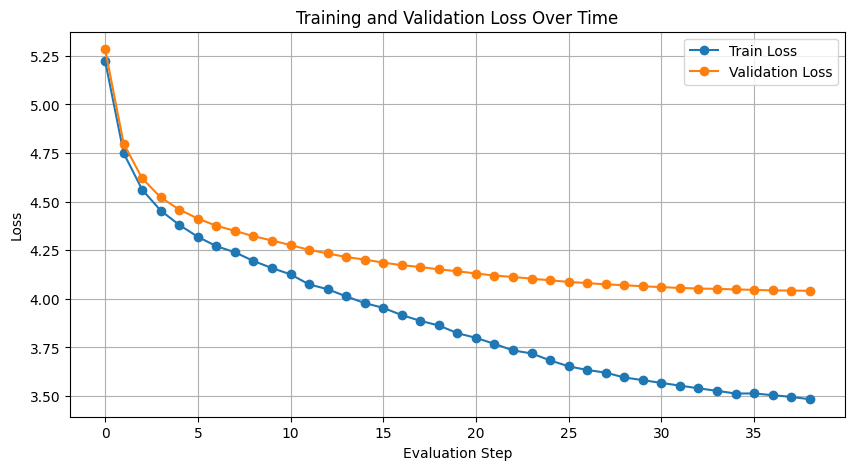

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss", marker='o')
plt.plot(val_losses, label="Validation Loss", marker='o')
plt.xlabel("Evaluation Step")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Over Time")
plt.legend()
plt.grid()
plt.show()

In [15]:
input_tokens = tokenizer.encode("Buongiorno ")
input_tokens = torch.tensor(
    input_tokens, dtype=torch.long).unsqueeze(0).to(config.device)

model.eval()
with torch.no_grad():
    output = model.generate(input_tokens=input_tokens, max_new_tokens=100)

print(tokenizer.decode(output[0].tolist()))

Buongiorno a oggi pnulla a Tanti a dividermi in due giorni Pielloni.
Inifo a FOTOM TOTAIA CHhhahahahhahahaha ahaembessere quadsalvo devo conosce quelle invece nare il numero Un cannone 😬 Mi numero che l'avore 9 soldi te! 😜 Tutto ' sugusci
